
# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 04B — Inverse / Reciprocal Short-Signal Research

**Purpose:** investigate whether SuperbCommand can be reused symmetrically for short-side signal generation by applying the unchanged indicator to reciprocal price series.

This notebook is an **experimental side branch**. It does not replace the main notebook sequence:

- 05 — Portfolio Construction
- 06 — Baseline Backtests
- 07 — Walk-Forward Optimisation
- etc.

### Core hypothesis

The existing `OUT` state was designed as a **long-side exit signal**, not as a short-entry signal.

Therefore:

\[
SC(P_t)=OUT
\]

should not automatically imply:

\[
SHORT
\]

Instead, define a reciprocal synthetic price series:

\[
I_t=\frac{K}{P_t}
\]

and apply the same SuperbCommand logic to \(I_t\).

A candidate short signal becomes:

\[
SC(P_t)=OUT
\quad \text{and} \quad
SC(I_t)=HELD
\]

or, more specifically, a short-entry opportunity may be associated with:

\[
SC(I_t)=EARLY\_REVERSAL
\]

### Important distinction

The reciprocal series is used only for **signal generation**.

The economic P&L of an actual short position in the original instrument is still based on the original asset return:

\[
r^{short}_{t}\approx-r_t
\]

subject to financing, futures carry, transaction costs and implementation details.

The reciprocal series is **not** treated as a tradable inverse ETF.

### Research discipline

- No signal hyperparameters are changed.
- No short intensity is optimised.
- 2026 remains locked.
- The first objective is to determine whether reciprocal SuperbCommand states contain useful information about future **negative** original-asset returns.


In [1]:

# ============================================================
# 4B.1 — IMPORTS, DRIVE & PROJECT CONFIGURATION
# ============================================================
from __future__ import annotations

import json
import sys
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}
RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 04B cannot run with the holdout unlocked.")

META_PATH = PATHS["data_processed"] / "prototype_universe_metadata.csv"
OHLC_PATH = PATHS["data_raw"] / "prototype_yahoo_ohlc_adjusted.parquet"

if not META_PATH.exists():
    raise FileNotFoundError("Run Notebook 01 first.")
if not OHLC_PATH.exists():
    raise FileNotFoundError("Run Notebook 02 first.")

meta = pd.read_csv(META_PATH, index_col=0)
ohlc = pd.read_parquet(OHLC_PATH)
ohlc.index = pd.to_datetime(ohlc.index)

if ohlc.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination detected.")

tickers = meta.index.tolist()

print("Markets:", len(tickers))
print("Research:", ohlc.index.min().date(), "→", ohlc.index.max().date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Markets: 11
Research: 2005-01-03 → 2025-12-31
2026 holdout: LOCKED



## 4B.2 Reuse the definitive SuperbCommand parameters

Notebook 04B uses the same parameters as Notebook 02.

No short-specific tuning is permitted here.


In [2]:

# ============================================================
# 4B.2 — DEFINITIVE PARAMETERS
# ============================================================
PARAMS = {
    "smoothing_length": 5,
    "fast_length": 20,
    "slow_length": 50,
    "signal_length": 25,
    "direction_length": 2,
    "bb_length": 20,
    "bb_smoothing": 5,
    "upper_bb_multiplier": 1.0,
    "lower_bb_multiplier": 2.0,
    "atr_len": 10,
    "supertrend_factor": 3.0,
    "training_data_period": 100,
    "high_vol_guess": 0.75,
    "mid_vol_guess": 0.50,
    "low_vol_guess": 0.25,
    "standby_weeks": 8,
}
pd.Series(PARAMS, name="value").to_frame()


,value
smoothing_length,5.00
fast_length,20.00
slow_length,50.00
signal_length,25.00
direction_length,2.00
bb_length,20.00
bb_smoothing,5.00
upper_bb_multiplier,1.00
lower_bb_multiplier,2.00
atr_len,10.00



## 4B.3 Reciprocal OHLC construction

For a positive price series \(P_t\), define:

\[
I_t=\frac{K}{P_t}
\]

with arbitrary positive constant \(K\).

To preserve OHLC ordering under inversion:

\[
Open^{inv}=\frac{K}{Open}
\]

\[
High^{inv}=\frac{K}{Low}
\]

\[
Low^{inv}=\frac{K}{High}
\]

\[
Close^{inv}=\frac{K}{Close}
\]

The high/low swap is essential because inversion reverses ordering.


In [3]:

# ============================================================
# 4B.3 — DAILY → WEEKLY & RECIPROCAL OHLC
# ============================================================
RECIPROCAL_SCALE = 10_000.0

def weekly_bars_for(ticker):
    d = ohlc[ticker].dropna(how="all").copy()
    w = pd.DataFrame({
        "open": d["Open"].resample("W-FRI").first(),
        "high": d["High"].resample("W-FRI").max(),
        "low": d["Low"].resample("W-FRI").min(),
        "close": d["Close"].resample("W-FRI").last(),
    }).dropna(subset=["close"])
    return w.loc[w.index <= RESEARCH_END]

def reciprocal_ohlc(df, k=RECIPROCAL_SCALE):
    x = df.copy()

    if (x[["open", "high", "low", "close"]] <= 0).any().any():
        raise ValueError("Reciprocal transform requires strictly positive OHLC prices.")

    inv = pd.DataFrame(index=x.index)
    inv["open"] = k / x["open"]
    inv["high"] = k / x["low"]
    inv["low"] = k / x["high"]
    inv["close"] = k / x["close"]

    if (inv["high"] < inv["low"]).any():
        raise RuntimeError("Reciprocal OHLC high/low ordering failed.")

    return inv

weekly_original = {t: weekly_bars_for(t) for t in tickers}
weekly_inverse = {t: reciprocal_ohlc(weekly_original[t]) for t in tickers}

print("Constructed reciprocal weekly OHLC for", len(weekly_inverse), "markets.")


Constructed reciprocal weekly OHLC for 11 markets.


## 4B.4 SuperbCommand mathematical primitives

In [4]:

# ============================================================
# 4B.4 — PRIMITIVES
# ============================================================
def pine_ema(s, length):
    return s.ewm(span=length, adjust=False, min_periods=length).mean()

def supersmoother(s, length):
    a1 = np.exp(-1.414 * np.pi / length)
    b1 = 2 * a1 * np.cos(1.414 * np.pi / length)
    c2 = b1
    c3 = -a1 * a1
    c1 = 1 - c2 - c3

    arr = s.to_numpy(float)
    out = np.full(len(arr), np.nan)

    for i in range(len(arr)):
        if np.isnan(arr[i]):
            continue
        prev_src = 0.0 if i == 0 or np.isnan(arr[i-1]) else arr[i-1]
        ss1 = 0.0 if i < 1 or np.isnan(out[i-1]) else out[i-1]
        ss2 = 0.0 if i < 2 or np.isnan(out[i-2]) else out[i-2]
        out[i] = c1 * (arr[i] + prev_src) / 2 + c2 * ss1 + c3 * ss2

    return pd.Series(out, index=s.index)

def true_range(df):
    pc = df["close"].shift(1)
    return pd.concat([
        df["high"] - df["low"],
        (df["high"] - pc).abs(),
        (df["low"] - pc).abs(),
    ], axis=1).max(axis=1)

def rma(s, length):
    a = s.to_numpy(float)
    out = np.full(len(a), np.nan)
    valid = np.where(~np.isnan(a))[0]

    if len(valid) < length:
        return pd.Series(out, index=s.index)

    start = valid[0] + length - 1
    if start >= len(a):
        return pd.Series(out, index=s.index)

    out[start] = np.nanmean(a[valid[0]:start+1])

    for i in range(start+1, len(a)):
        if np.isnan(a[i]):
            out[i] = out[i-1]
        else:
            out[i] = (out[i-1] * (length - 1) + a[i]) / length

    return pd.Series(out, index=s.index)

def crossover(a, b):
    if np.isscalar(b):
        b = pd.Series(b, index=a.index)
    return (a > b) & (a.shift(1) <= b.shift(1))

def crossunder(a, b):
    if np.isscalar(b):
        b = pd.Series(b, index=a.index)
    return (a < b) & (a.shift(1) >= b.shift(1))


In [5]:

# ============================================================
# 4B.5 — ADAPTIVE VOLATILITY CLUSTER + SUPERTREND
# ============================================================
def adaptive_centroid(atr, period, guesses=(.75, .50, .25), max_iter=100):
    a = atr.to_numpy(float)
    assigned = np.full(len(a), np.nan)
    cluster = np.full(len(a), np.nan)

    for t in range(period - 1, len(a)):
        window = a[t-period+1:t+1]

        if np.isnan(window).any() or not (a[t] > 0):
            continue

        lo, hi = np.min(window), np.max(window)
        cents = np.array([lo + (hi - lo) * g for g in guesses], float)

        for _ in range(max_iter):
            groups = [[], [], []]

            for v in window:
                ds = np.abs(v - cents)
                m = np.min(ds)
                winners = np.flatnonzero(ds == m)
                if len(winners) == 1:
                    groups[winners[0]].append(v)

            new = np.array([
                np.mean(g) if len(g) else np.nan
                for g in groups
            ])

            if np.any(np.isnan(new)):
                break

            if np.array_equal(new, cents) or np.allclose(new, cents, rtol=0, atol=1e-12):
                cents = new
                break

            cents = new

        if np.any(np.isnan(cents)):
            continue

        ds = np.abs(a[t] - cents)
        k = int(np.argmin(ds))

        cluster[t] = k
        assigned[t] = cents[k]

    return (
        pd.Series(assigned, index=atr.index),
        pd.Series(cluster, index=atr.index),
    )

def pine_supertrend(df, atr_value, factor):
    n = len(df)

    st = np.full(n, np.nan)
    direction = np.full(n, np.nan)
    upper = np.full(n, np.nan)
    lower = np.full(n, np.nan)

    h = df["high"].to_numpy(float)
    l = df["low"].to_numpy(float)
    cl = df["close"].to_numpy(float)
    av = atr_value.to_numpy(float)

    for i in range(n):
        if np.isnan(av[i]):
            continue

        src = (h[i] + l[i]) / 2
        ub = src + factor * av[i]
        lb = src - factor * av[i]

        prev_lb = 0.0 if i == 0 or np.isnan(lower[i-1]) else lower[i-1]
        prev_ub = 0.0 if i == 0 or np.isnan(upper[i-1]) else upper[i-1]
        prev_close = 0.0 if i == 0 or np.isnan(cl[i-1]) else cl[i-1]

        lb = lb if (lb > prev_lb or prev_close < prev_lb) else prev_lb
        ub = ub if (ub < prev_ub or prev_close > prev_ub) else prev_ub

        lower[i] = lb
        upper[i] = ub

        if i == 0 or np.isnan(av[i-1]):
            d = 1
        else:
            pst = st[i-1]
            if not np.isnan(pst) and np.isclose(pst, prev_ub, rtol=0, atol=1e-12):
                d = -1 if cl[i] > ub else 1
            else:
                d = 1 if cl[i] < lb else -1

        direction[i] = d
        st[i] = lb if d == -1 else ub

    return (
        pd.Series(st, index=df.index),
        pd.Series(direction, index=df.index),
    )



## 4B.6 Minimal SuperbCommand state engine

Notebook 04B reproduces the full state logic required to identify:

- reciprocal Early Reversal;
- reciprocal Pullback;
- reciprocal Profit-Taking;
- reciprocal Standby;
- reciprocal strategic held/out state.

It does not change any indicator logic.


In [6]:

# ============================================================
# 4B.6 — SUPERBCOMMAND ENGINE
# ============================================================
def superbcommand(df, p=PARAMS):
    z = df.copy()

    z["smoothed_price"] = supersmoother(z["close"], p["smoothing_length"])
    z["fast_ma"] = pine_ema(z["smoothed_price"], p["fast_length"])
    z["slow_ma"] = pine_ema(z["smoothed_price"], p["slow_length"])
    z["oscillator"] = z["fast_ma"] - z["slow_ma"]
    z["signal_line"] = pine_ema(z["oscillator"], p["signal_length"])
    z["spread"] = z["oscillator"] - z["signal_line"]

    z["oscillator_slope"] = z["oscillator"] - z["oscillator"].shift(p["direction_length"])
    z["osc_rising"] = z["oscillator_slope"] > 0
    z["osc_falling"] = z["oscillator_slope"] < 0
    z["osc_turns_red"] = z["osc_falling"] & ~z["osc_falling"].shift(1).fillna(False)

    raw_std = z["spread"].rolling(
        p["bb_length"],
        min_periods=p["bb_length"]
    ).std(ddof=0)

    z["spread_std"] = pine_ema(raw_std, p["bb_smoothing"])
    z["upper_bb"] = z["signal_line"] + p["upper_bb_multiplier"] * z["spread_std"]
    z["lower_bb"] = z["signal_line"] - p["lower_bb_multiplier"] * z["spread_std"]

    z["atr"] = rma(true_range(z), p["atr_len"])

    assigned, cluster = adaptive_centroid(
        z["atr"],
        p["training_data_period"],
        (p["high_vol_guess"], p["mid_vol_guess"], p["low_vol_guess"]),
    )

    z["assigned_centroid"] = assigned
    z["vol_cluster"] = cluster

    st, stdir = pine_supertrend(
        z,
        assigned,
        p["supertrend_factor"],
    )

    z["supertrend"] = st
    z["supertrend_dir"] = stdir
    z["supertrend_bullish"] = stdir < 0
    z["supertrend_bearish"] = stdir > 0

    z["signal_cross_above_zero"] = crossover(z["signal_line"], 0)
    z["osc_cross_above_lower_bb"] = crossover(z["oscillator"], z["lower_bb"])
    z["osc_cross_below_upper_bb"] = crossunder(z["oscillator"], z["upper_bb"])

    for col in [
        "start_early_reversal",
        "start_pullback",
        "start_profit_taking",
        "position_entry_event",
        "position_exit_event",
        "standby_anchor_event",
        "position_held",
        "standby_active",
        "early_reversal_active",
        "pullback_active",
        "profit_taking_active",
    ]:
        z[col] = False

    z["zone_mode"] = 0

    zone = 0
    exitmode = 0
    sawbelow = False
    sawabove = False
    resume = False
    held = False
    standby = False
    elapsed = 0
    standby_resume_er = False
    saved_exitmode = 0

    for j in range(len(z)):
        o = z["oscillator"].iat[j]
        sig = z["signal_line"].iat[j]
        ub = z["upper_bb"].iat[j]
        lb = z["lower_bb"].iat[j]
        bull = bool(z["supertrend_bullish"].iat[j])
        bear = bool(z["supertrend_bearish"].iat[j])
        rising = bool(z["osc_rising"].iat[j])
        falling = bool(z["osc_falling"].iat[j])
        turnsred = bool(z["osc_turns_red"].iat[j])
        sigx = bool(z["signal_cross_above_zero"].iat[j])

        valid = not any(pd.isna(v) for v in [o, sig, ub, lb])

        startER = False
        startPB = False
        startPT = False
        entryEv = False
        exitEv = False
        anchorEv = False

        accum_before = zone in (1, 2)
        can_search = (not accum_before) and (not standby)
        secondary = held and (not standby)
        between = valid and o >= lb and o <= ub
        above = valid and o > ub

        if standby:
            sawbelow = False
            sawabove = False
            resume = False
        elif can_search and valid:
            if o < lb:
                sawbelow = True
            if o > 0 and o > ub:
                sawabove = True
            if o <= 0:
                sawabove = False
        else:
            sawbelow = False
            sawabove = False

        if valid and (o <= lb or o > ub):
            resume = False

        riskon_er = (
            valid and held and can_search and not standby
            and sawbelow and o > lb and rising and bull
        )

        out_er = (
            valid and (not held) and (not standby)
            and bull and o > lb
        )

        er_entry = riskon_er or out_er

        pb_entry = (
            valid and secondary and can_search and sawabove
            and o > 0 and o >= lb and o < ub and falling
        )

        pb_resume = (
            valid and secondary and can_search and resume
            and o >= 0 and between and turnsred
        )

        pt_entry = (
            valid and secondary and can_search
            and not er_entry and not pb_entry and not pb_resume
            and o > 0 and turnsred
        )

        if standby:
            zone = 0
            exitmode = 0
            sawbelow = False
            sawabove = False
            resume = False

            if valid and o > lb:
                standby = False
                elapsed = 0

                if standby_resume_er:
                    zone = 1
                    exitmode = saved_exitmode
                else:
                    zone = 0

                standby_resume_er = False
                saved_exitmode = 0

            else:
                elapsed += 1

                if elapsed >= p["standby_weeks"]:
                    standby = False
                    elapsed = 0
                    standby_resume_er = False
                    saved_exitmode = 0
                    held = False
                    exitEv = True

        else:
            start_standby = valid and held and o < lb and bear

            if start_standby:
                standby_resume_er = (zone == 1)
                saved_exitmode = exitmode if zone == 1 else 0

                zone = 0
                exitmode = 0
                sawbelow = False
                sawabove = False
                resume = False

                standby = True
                elapsed = 0
                anchorEv = True

            else:
                if zone == 1:
                    if exitmode == 1 and sigx:
                        zone = 0
                        exitmode = 0

                    elif exitmode == 2 and turnsred:
                        exitmode = 0

                        if secondary and above:
                            zone = 3
                            startPT = True
                            resume = False

                        elif secondary and between and o >= 0:
                            zone = 2
                            startPB = True
                            resume = True

                        else:
                            zone = 0
                            resume = False

                elif zone == 2:
                    if valid and (o < 0 or o > ub or o < lb):
                        zone = 0
                        resume = False

                    elif valid and rising and between:
                        zone = 0
                        resume = True

                else:
                    if er_entry:
                        zone = 1
                        startER = True
                        exitmode = 1 if sig < 0 else 2
                        sawbelow = False
                        sawabove = False
                        resume = False

                    elif pb_entry or pb_resume:
                        zone = 2
                        startPB = True
                        exitmode = 0
                        sawabove = False
                        sawbelow = False
                        resume = True

                    elif zone == 3:
                        if (not falling) or (not held):
                            zone = 0

                    elif pt_entry:
                        zone = 3
                        startPT = True
                        resume = False

                if (not held) and startER:
                    held = True
                    entryEv = True

        z.at[z.index[j], "start_early_reversal"] = startER
        z.at[z.index[j], "start_pullback"] = startPB
        z.at[z.index[j], "start_profit_taking"] = startPT
        z.at[z.index[j], "position_entry_event"] = entryEv
        z.at[z.index[j], "position_exit_event"] = exitEv
        z.at[z.index[j], "standby_anchor_event"] = anchorEv
        z.at[z.index[j], "position_held"] = held
        z.at[z.index[j], "standby_active"] = standby
        z.at[z.index[j], "zone_mode"] = zone
        z.at[z.index[j], "early_reversal_active"] = (zone == 1)
        z.at[z.index[j], "pullback_active"] = (zone == 2)
        z.at[z.index[j], "profit_taking_active"] = (zone == 3)

    return z



## 4B.7 Run SuperbCommand on original and reciprocal markets

The original and reciprocal state machines are evaluated independently.

This allows four broad combinations:

1. original long / reciprocal out;
2. original out / reciprocal long;
3. both out;
4. both long.

The fourth case is especially important because simultaneous long signals would indicate ambiguity rather than a clean directional regime.


In [7]:

# ============================================================
# 4B.7 — RUN ORIGINAL + RECIPROCAL ENGINES
# ============================================================
original_signals = {}
inverse_signals = {}

for ticker in tickers:
    original_signals[ticker] = superbcommand(weekly_original[ticker])
    inverse_signals[ticker] = superbcommand(weekly_inverse[ticker])

    print(
        f"{ticker:8s} | original held weeks="
        f"{int(original_signals[ticker]['position_held'].sum()):4d} | "
        f"inverse held weeks="
        f"{int(inverse_signals[ticker]['position_held'].sum()):4d}"
    )


/tmp/ipykernel_1438/1771670737.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"] = z["osc_falling"] & ~z["osc_falling"].shift(1).fillna(False)
/tmp/ipykernel_1438/1771670737.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"] = z["osc_falling"] & ~z["osc_falling"].shift(1).fillna(False)


SPY      | original held weeks= 867 | inverse held weeks= 572


/tmp/ipykernel_1438/1771670737.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"] = z["osc_falling"] & ~z["osc_falling"].shift(1).fillna(False)
/tmp/ipykernel_1438/1771670737.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"] = z["osc_falling"] & ~z["osc_falling"].shift(1).fillna(False)


EFA      | original held weeks= 779 | inverse held weeks= 668


/tmp/ipykernel_1438/1771670737.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"] = z["osc_falling"] & ~z["osc_falling"].shift(1).fillna(False)
/tmp/ipykernel_1438/1771670737.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"] = z["osc_falling"] & ~z["osc_falling"].shift(1).fillna(False)


...

DBC      | original held weeks= 708 | inverse held weeks= 719


/tmp/ipykernel_1438/1771670737.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"] = z["osc_falling"] & ~z["osc_falling"].shift(1).fillna(False)
/tmp/ipykernel_1438/1771670737.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"] = z["osc_falling"] & ~z["osc_falling"].shift(1).fillna(False)


UUP      | original held weeks= 676 | inverse held weeks= 644


/tmp/ipykernel_1438/1771670737.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"] = z["osc_falling"] & ~z["osc_falling"].shift(1).fillna(False)
/tmp/ipykernel_1438/1771670737.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z["osc_turns_red"] = z["osc_falling"] & ~z["osc_falling"].shift(1).fillna(False)


BTC-USD  | original held weeks= 395 | inverse held weeks= 181



## 4B.8 Reciprocal short-signal diagnostics

The primary candidate short states are:

### Candidate A — Reciprocal Early Reversal

\[
Inverse\ Early\ Reversal
\]

### Candidate B — Reciprocal Held

\[
Inverse\ position\_held=True
\]

### Candidate C — Original OUT + Reciprocal Held

\[
Original\ position\_held=False
\]

and

\[
Inverse\ position\_held=True
\]

Candidate C is the cleanest directional formulation because it requires both:

- no long-side conviction;
- positive trend conviction on the reciprocal series.


In [8]:

# ============================================================
# 4B.8 — BUILD COMBINED DIAGNOSTIC PANEL
# ============================================================
parts = []

for ticker in tickers:
    o = original_signals[ticker].copy()
    i = inverse_signals[ticker].copy()

    idx = o.index.intersection(i.index)
    o = o.loc[idx]
    i = i.loc[idx]

    x = pd.DataFrame(index=idx)

    x["original_close"] = o["close"]
    x["original_return"] = o["close"].pct_change(fill_method=None)

    x["original_held"] = o["position_held"].astype(bool)
    x["inverse_held"] = i["position_held"].astype(bool)

    x["inverse_early_reversal"] = i["start_early_reversal"].astype(bool)
    x["inverse_pullback"] = i["start_pullback"].astype(bool)
    x["inverse_profit_taking"] = i["start_profit_taking"].astype(bool)
    x["inverse_standby"] = i["standby_active"].astype(bool)

    x["candidate_short_inverse_ER"] = x["inverse_early_reversal"]
    x["candidate_short_inverse_held"] = x["inverse_held"]
    x["candidate_short_clean"] = (~x["original_held"]) & x["inverse_held"]

    x["ambiguous_both_held"] = x["original_held"] & x["inverse_held"]
    x["neutral_both_out"] = (~x["original_held"]) & (~x["inverse_held"])

    x["ticker"] = ticker
    x["asset_class"] = meta.loc[ticker, "asset_class"]

    parts.append(x.reset_index(names="date"))

diag = pd.concat(parts, ignore_index=True)

display(diag.head())


,date,original_close,original_return,original_held,inverse_held,inverse_early_reversal,inverse_pullback,inverse_profit_taking,inverse_standby,candidate_short_inverse_ER,candidate_short_inverse_held,candidate_short_clean,ambiguous_both_held,neutral_both_out,ticker,asset_class
0,2005-01-07,79.919548,NaN,False,False,False,False,False,False,False,False,False,False,True,SPY,equities
1,2005-01-14,79.784592,-0.001689,False,False,False,False,False,False,False,False,False,False,True,SPY,equities
2,2005-01-21,78.799400,-0.012348,False,False,False,False,False,False,False,False,False,False,True,SPY,equities
3,2005-01-28,79.238045,0.005567,False,False,False,False,False,False,False,False,False,False,True,SPY,equities
4,2005-02-04,81.127380,0.023844,False,False,False,False,False,False,False,False,False,False,True,SPY,equities



## 4B.9 Forward original-asset returns

A useful short signal should be followed by **negative original-asset returns**.

The same fixed horizons used in Notebook 03 are retained.


In [9]:

# ============================================================
# 4B.9 — FORWARD ORIGINAL-ASSET RETURNS
# ============================================================
HORIZONS = [1, 2, 4, 8, 13, 26, 52]

diag = diag.sort_values(["ticker", "date"]).copy()

for h in HORIZONS:
    diag[f"fwd_{h}w"] = (
        diag.groupby("ticker")["original_close"].shift(-h)
        / diag["original_close"]
        - 1.0
    )

print("Forward-return columns created.")


Forward-return columns created.


In [21]:

# ============================================================
# 4B.10 — CANDIDATE SHORT EVENT / STATE SUMMARY
# ============================================================
CANDIDATES = {
    "Inverse Early Reversal": "candidate_short_inverse_ER",
    "Inverse Held": "candidate_short_inverse_held",
    "Original OUT + Inverse Held": "candidate_short_clean",
}

rows = []

for name, col in CANDIDATES.items():
    s = diag[diag[col] == True]

    for h in HORIZONS:
        r = s[f"fwd_{h}w"].dropna()

        rows.append({
            "candidate": name,
            "horizon_weeks": h,
            "n": len(r),
            "mean_original_return": r.mean(),
            "median_original_return": r.median(),
            "negative_hit_rate": (r < 0).mean() if len(r) else np.nan,
            "mean_short_return_approx": (-r).mean() if len(r) else np.nan,
        })

candidate_summary = pd.DataFrame(rows)
display(candidate_summary)


,candidate,horizon_weeks,n,mean_original_return,median_original_return,negative_hit_rate,mean_short_return_approx
0,Inverse Early Reversal,1,76,0.001127,0.000946,0.434211,-0.001127
1,Inverse Early Reversal,2,76,0.000589,0.001352,0.460526,-0.000589
2,Inverse Early Reversal,4,76,0.003856,0.005983,0.434211,-0.003856
3,Inverse Early Reversal,8,75,0.001829,0.006389,0.440000,-0.001829
4,Inverse Early Reversal,13,75,0.007306,0.005083,0.426667,-0.007306
5,Inverse Early Reversal,26,75,0.044459,0.015127,0.386667,-0.044459
6,Inverse Early Reversal,52,73,0.057318,0.034336,0.383562,-0.057318
7,Inverse Held,1,6341,0.001459,0.000893,0.453556,-0.001459
8,Inverse Held,2,6337,0.002833,0.001938,0.442954,-0.002833
9,Inverse Held,4,6329,0.005810,0.003353,0.434034,-0.005810



## 4B.11 Market-level consistency

This is critical.

A candidate short architecture should not be judged solely by aggregate results, especially if Bitcoin or one crisis episode dominates the sample.


In [11]:

# ============================================================
# 4B.11 — MARKET-LEVEL SHORT-SIGNAL CONSISTENCY
# ============================================================
PRIMARY_SHORT_SIGNAL = "candidate_short_clean"
PRIMARY_HORIZON = 13

rows = []

for ticker, s in diag.groupby("ticker"):
    r = s.loc[s[PRIMARY_SHORT_SIGNAL], f"fwd_{PRIMARY_HORIZON}w"].dropna()

    rows.append({
        "ticker": ticker,
        "asset_class": meta.loc[ticker, "asset_class"],
        "observations": len(r),
        "mean_original_return": r.mean() if len(r) else np.nan,
        "median_original_return": r.median() if len(r) else np.nan,
        "negative_hit_rate": (r < 0).mean() if len(r) else np.nan,
        "approx_short_mean_return": (-r).mean() if len(r) else np.nan,
    })

market_short_summary = pd.DataFrame(rows).set_index("ticker")
display(market_short_summary)


,asset_class,observations,mean_original_return,median_original_return,negative_hit_rate,approx_short_mean_return
ticker,,,,,,
BTC-USD,crypto,60,0.271584,0.180511,0.333333,-0.271584
DBC,commodities,211,0.004075,0.008197,0.464455,-0.004075
EEM,equities,173,0.018745,0.001935,0.491329,-0.018745
EFA,equities,192,-0.006892,0.003426,0.500000,0.006892
GLD,commodities,101,0.035834,0.035746,0.267327,-0.035834
IEF,rates,98,0.008790,0.013295,0.316327,-0.008790
SHY,rates,90,-0.002663,0.001533,0.422222,0.002663
SPY,equities,109,-0.024527,-0.037400,0.568807,0.024527
TIP,rates,136,0.009902,0.015622,0.250000,-0.009902



## 4B.12 Ambiguity diagnostics

If SuperbCommand behaves symmetrically under inversion, original and reciprocal signals may sometimes overlap.

We therefore quantify:

- both original and reciprocal held;
- both out;
- original only;
- reciprocal only.

A useful long/short architecture should have a meaningful neutral state rather than forcing exposure at all times.


In [12]:

# ============================================================
# 4B.12 — SIGNAL COMBINATION FREQUENCIES
# ============================================================
def combo_label(row):
    if row["original_held"] and row["inverse_held"]:
        return "BOTH_HELD"
    if row["original_held"] and not row["inverse_held"]:
        return "LONG_ONLY"
    if (not row["original_held"]) and row["inverse_held"]:
        return "SHORT_ONLY"
    return "BOTH_OUT"

diag["signal_combo"] = diag.apply(combo_label, axis=1)

combo_summary = (
    diag.groupby(["asset_class", "signal_combo"])
    .size()
    .rename("weeks")
    .reset_index()
)

display(combo_summary)

overall_combo = (
    diag["signal_combo"]
    .value_counts(normalize=True)
    .rename("share")
    .to_frame()
)

display(overall_combo)


,asset_class,signal_combo,weeks
0,commodities,BOTH_HELD,1019
1,commodities,BOTH_OUT,260
2,commodities,LONG_ONLY,542
3,commodities,SHORT_ONLY,312
4,crypto,BOTH_HELD,121
5,crypto,BOTH_OUT,134
6,crypto,LONG_ONLY,274
7,crypto,SHORT_ONLY,60
8,equities,BOTH_HELD,1407
9,equities,BOTH_OUT,365


,share
signal_combo,
BOTH_HELD,0.424274
LONG_ONLY,0.319085
SHORT_ONLY,0.133773
BOTH_OUT,0.122867



## 4B.13 Simple reciprocal short backtest

This is a **diagnostic strategy**, not yet a final portfolio specification.

Rules:

\[
+1 \quad \text{if Original Held and Inverse not Held}
\]

\[
-1 \quad \text{if Original OUT and Inverse Held}
\]

\[
0 \quad \text{otherwise}
\]

Thus:

- conflicting signals → cash;
- neither signal → cash;
- only original trend → long;
- only reciprocal trend → short.

All signals are shifted by one week before returns are earned.


In [13]:

# ============================================================
# 4B.13 — TRI-STATE LONG / CASH / SHORT BACKTEST
# ============================================================
ONE_WAY_COST_BPS = (
    float(CFG["defaults"]["transaction_cost_bps_one_way"])
    + float(CFG["defaults"]["slippage_bps_one_way"])
)
ONE_WAY_COST = ONE_WAY_COST_BPS / 10_000

bt_parts = []

for ticker, s in diag.groupby("ticker"):
    x = s.sort_values("date").copy()

    x["target_exposure"] = 0.0
    x.loc[x["signal_combo"] == "LONG_ONLY", "target_exposure"] = 1.0
    x.loc[x["signal_combo"] == "SHORT_ONLY", "target_exposure"] = -1.0

    x["exposure"] = x["target_exposure"].shift(1)
    x["turnover"] = x["exposure"].diff().abs()

    first_valid = x["exposure"].first_valid_index()
    if first_valid is not None:
        x.loc[first_valid, "turnover"] = abs(x.loc[first_valid, "exposure"])

    x["transaction_cost"] = x["turnover"].fillna(0) * ONE_WAY_COST
    x["strategy_return"] = (
        x["exposure"] * x["original_return"]
        - x["transaction_cost"]
    ).fillna(0.0)

    bt_parts.append(x)

bt = pd.concat(bt_parts, ignore_index=True)


In [14]:

# ============================================================
# 4B.14 — COMPARE TRI-STATE VS LONG/CASH BASELINE
# ============================================================
TRADING_WEEKS_PER_YEAR = 52

def max_drawdown(r):
    r = pd.Series(r).dropna()
    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1
    return dd.min()

def metrics(r):
    r = pd.Series(r).dropna()

    if len(r) < 2:
        return {}

    years = len(r) / TRADING_WEEKS_PER_YEAR
    wealth = (1 + r).prod()
    cagr = wealth ** (1 / years) - 1 if wealth > 0 else np.nan
    vol = r.std(ddof=1) * np.sqrt(TRADING_WEEKS_PER_YEAR)
    sharpe = r.mean() / r.std(ddof=1) * np.sqrt(TRADING_WEEKS_PER_YEAR)
    mdd = max_drawdown(r)

    return {
        "cagr": cagr,
        "ann_vol": vol,
        "sharpe": sharpe,
        "max_drawdown": mdd,
        "calmar": cagr / abs(mdd) if mdd != 0 else np.nan,
    }

comparison_rows = []

for ticker, s in bt.groupby("ticker"):
    s = s.sort_values("date").copy()

    # Tri-state reciprocal architecture
    tri = s["strategy_return"]

    # Long/cash baseline using original held state only
    base_target = s["original_held"].astype(float)
    base_exp = base_target.shift(1)
    base_turnover = base_exp.diff().abs()

    first_valid = base_exp.first_valid_index()
    if first_valid is not None:
        base_turnover.loc[first_valid] = abs(base_exp.loc[first_valid])

    base_ret = (
        base_exp * s["original_return"]
        - base_turnover.fillna(0) * ONE_WAY_COST
    ).fillna(0)

    m_tri = metrics(tri)
    m_base = metrics(base_ret)

    comparison_rows.append({
        "ticker": ticker,
        "asset_class": meta.loc[ticker, "asset_class"],
        "tri_cagr": m_tri.get("cagr"),
        "tri_sharpe": m_tri.get("sharpe"),
        "tri_max_drawdown": m_tri.get("max_drawdown"),
        "base_cagr": m_base.get("cagr"),
        "base_sharpe": m_base.get("sharpe"),
        "base_max_drawdown": m_base.get("max_drawdown"),
        "delta_cagr": m_tri.get("cagr") - m_base.get("cagr"),
        "delta_sharpe": m_tri.get("sharpe") - m_base.get("sharpe"),
    })

comparison = pd.DataFrame(comparison_rows).set_index("ticker")
display(comparison)


,asset_class,tri_cagr,tri_sharpe,tri_max_drawdown,base_cagr,base_sharpe,base_max_drawdown,delta_cagr,delta_sharpe
ticker,,,,,,,,,
BTC-USD,crypto,0.269153,0.707727,-0.808424,0.615366,1.118090,-0.656423,-0.346213,-0.410363
DBC,commodities,0.009202,0.135924,-0.442137,-0.016513,-0.026746,-0.694304,0.025715,0.162670
EEM,equities,-0.010095,0.037864,-0.647860,0.041490,0.324608,-0.425509,-0.051585,-0.286745
EFA,equities,-0.002142,0.053379,-0.510046,0.056898,0.457816,-0.331486,-0.059039,-0.404436
GLD,commodities,0.024904,0.271202,-0.413963,0.067019,0.517799,-0.447714,-0.042115,-0.246597
IEF,rates,0.001050,0.046400,-0.130613,0.026336,0.460098,-0.245918,-0.025286,-0.413698
SHY,rates,0.015994,1.375690,-0.019038,0.016611,1.409755,-0.019038,-0.000616,-0.034065
SPY,equities,0.017956,0.202051,-0.437409,0.107508,0.792460,-0.318290,-0.089552,-0.590409
TIP,rates,0.002842,0.084815,-0.158006,0.026280,0.531030,-0.124379,-0.023438,-0.446216



## 4B.15 Equal-weight aggregate diagnostic

As in Notebook 04, this is only a coarse equal-weight aggregate.

Portfolio construction belongs in Notebook 05.


In [15]:

# ============================================================
# 4B.15 — EQUAL-WEIGHT AGGREGATE
# ============================================================
tri_matrix = bt.pivot(index="date", columns="ticker", values="strategy_return")
tri_port = tri_matrix.mean(axis=1, skipna=True)

base_series = {}

for ticker, s in bt.groupby("ticker"):
    s = s.sort_values("date").copy()

    base_target = s["original_held"].astype(float)
    base_exp = base_target.shift(1)
    base_turnover = base_exp.diff().abs()

    first_valid = base_exp.first_valid_index()
    if first_valid is not None:
        base_turnover.loc[first_valid] = abs(base_exp.loc[first_valid])

    base_series[ticker] = pd.Series(
        (
            base_exp * s["original_return"]
            - base_turnover.fillna(0) * ONE_WAY_COST
        ).fillna(0).to_numpy(),
        index=s["date"],
    )

base_matrix = pd.concat(base_series, axis=1).sort_index()
base_port = base_matrix.mean(axis=1, skipna=True)

aggregate_comparison = pd.DataFrame(
    {
        "Long/Cash baseline": metrics(base_port),
        "Reciprocal tri-state": metrics(tri_port),
    }
).T

display(aggregate_comparison)


,cagr,ann_vol,sharpe,max_drawdown,calmar
Long/Cash baseline,0.070072,0.068501,1.023648,-0.137594,0.509270
Reciprocal tri-state,0.027356,0.062968,0.460142,-0.169232,0.161648


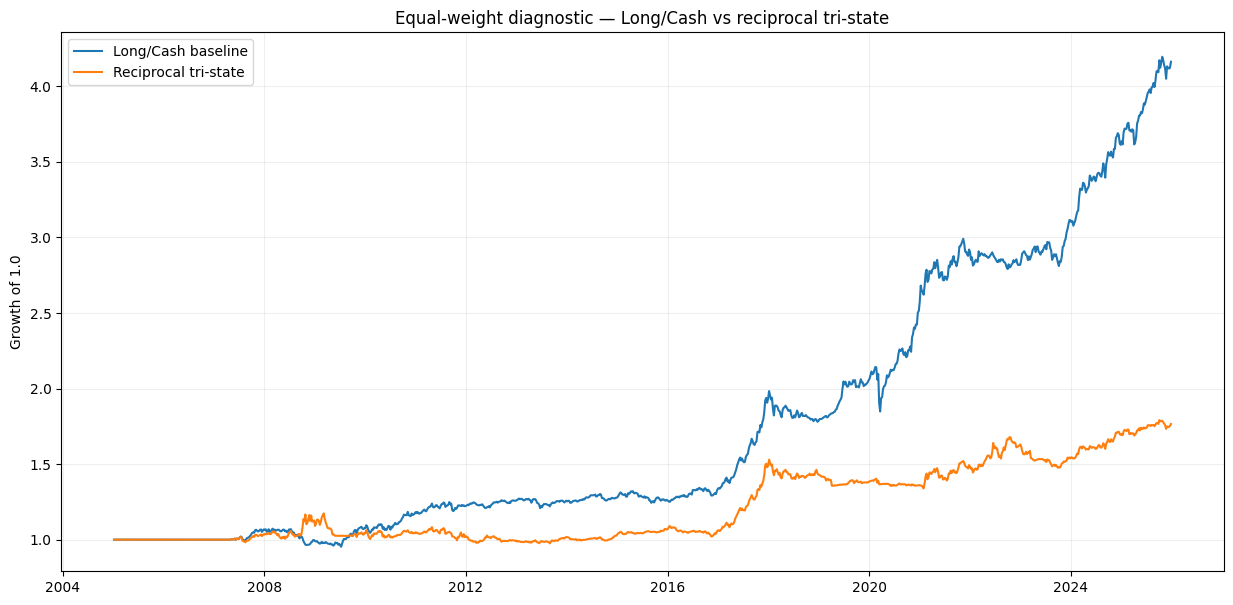

In [16]:

# ============================================================
# 4B.16 — EQUITY CURVE COMPARISON
# ============================================================
fig, ax = plt.subplots(figsize=(15, 7))

for label, r in {
    "Long/Cash baseline": base_port,
    "Reciprocal tri-state": tri_port,
}.items():
    eq = (1 + r.fillna(0)).cumprod()
    ax.plot(eq.index, eq, label=label)

ax.set_title("Equal-weight diagnostic — Long/Cash vs reciprocal tri-state")
ax.set_ylabel("Growth of 1.0")
ax.legend()
ax.grid(alpha=0.2)
plt.show()



## 4B.17 Fixed crisis-period comparison

This asks whether reciprocal short signals improve the strategy specifically during prolonged dislocations.


In [17]:

# ============================================================
# 4B.17 — STRESS PERIODS
# ============================================================
STRESS_PERIODS = {
    "Global Financial Crisis": ("2007-07-01", "2009-03-31"),
    "Euro-area stress": ("2011-05-01", "2012-07-31"),
    "COVID crash": ("2020-02-01", "2020-04-30"),
    "2022 inflation/rates shock": ("2022-01-01", "2022-12-31"),
}

rows = []

for name, (start, end) in STRESS_PERIODS.items():
    for strategy, r in {
        "Long/Cash baseline": base_port,
        "Reciprocal tri-state": tri_port,
    }.items():
        x = r.loc[start:end].dropna()

        if len(x) == 0:
            continue

        rows.append({
            "period": name,
            "strategy": strategy,
            "weeks": len(x),
            "total_return": (1 + x).prod() - 1,
            "max_drawdown": max_drawdown(x),
            "worst_week": x.min(),
        })

stress = pd.DataFrame(rows)
display(stress)


,period,strategy,weeks,total_return,max_drawdown,worst_week
0,Global Financial Crisis,Long/Cash baseline,91,-0.025419,-0.101422,-0.020196
1,Global Financial Crisis,Reciprocal tri-state,91,0.092560,-0.066296,-0.054929
2,Euro-area stress,Long/Cash baseline,65,0.005771,-0.048228,-0.033839
3,Euro-area stress,Reciprocal tri-state,65,-0.063183,-0.090525,-0.028618
4,COVID crash,Long/Cash baseline,12,-0.038056,-0.137594,-0.093356
5,COVID crash,Reciprocal tri-state,12,-0.014547,-0.027010,-0.019118
6,2022 inflation/rates shock,Long/Cash baseline,52,-0.029359,-0.040160,-0.018910
7,2022 inflation/rates shock,Reciprocal tri-state,52,0.098523,-0.063080,-0.021138



## 4B.18 Save outputs and validate

Notebook 04B remains an exploratory side branch. Its results should be used to decide whether reciprocal signal generation deserves later inclusion in the formal strategy research sequence.


In [18]:

# ============================================================
# 4B.18 — SAVE OUTPUTS
# ============================================================
CANDIDATE_PATH = PATHS["results"] / "04B_inverse_short_candidate_summary.csv"
MARKET_PATH = PATHS["results"] / "04B_market_short_summary.csv"
COMBO_PATH = PATHS["results"] / "04B_signal_combo_summary.csv"
COMPARISON_PATH = PATHS["results"] / "04B_market_strategy_comparison.csv"
AGG_PATH = PATHS["results"] / "04B_aggregate_comparison.csv"
STRESS_PATH = PATHS["results"] / "04B_stress_comparison.csv"
DIAG_PATH = PATHS["data_processed"] / "04B_inverse_short_diagnostic_panel.parquet"

candidate_summary.to_csv(CANDIDATE_PATH, index=False)
market_short_summary.to_csv(MARKET_PATH)
combo_summary.to_csv(COMBO_PATH, index=False)
comparison.to_csv(COMPARISON_PATH)
aggregate_comparison.to_csv(AGG_PATH)
stress.to_csv(STRESS_PATH, index=False)
diag.to_parquet(DIAG_PATH)

print("Saved 04B outputs.")


Saved 04B outputs.


In [19]:

# ============================================================
# 4B.19 — VALIDATION SUITE
# ============================================================
checks = {}

checks["holdout_absent"] = pd.to_datetime(diag["date"]).max() <= RESEARCH_END
checks["all_markets_present"] = set(diag["ticker"].unique()) == set(tickers)
checks["candidate_signals_exist"] = (
    int(diag["candidate_short_inverse_ER"].sum()) > 0
    and int(diag["candidate_short_clean"].sum()) > 0
)
checks["signal_combos_valid"] = set(diag["signal_combo"].unique()).issubset(
    {"LONG_ONLY", "SHORT_ONLY", "BOTH_HELD", "BOTH_OUT"}
)
checks["output_files_written"] = all(
    p.exists()
    for p in [
        CANDIDATE_PATH,
        MARKET_PATH,
        COMBO_PATH,
        COMPARISON_PATH,
        AGG_PATH,
        STRESS_PATH,
        DIAG_PATH,
    ]
)

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 04B validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 04B STATUS: PASS")
print("=" * 78)
print("Reciprocal short-signal research completed.")
print("No short-side hyperparameters were optimised.")
print("2026 holdout: NOT ACCESSED")
print("Main notebook sequence remains unchanged.")
print("Proceed next to Notebook 05 — Portfolio Construction.")


                  check  passed
         holdout_absent    True
    all_markets_present    True
candidate_signals_exist    True
    signal_combos_valid    True
   output_files_written    True

NOTEBOOK 04B STATUS: PASS
Reciprocal short-signal research completed.
No short-side hyperparameters were optimised.
2026 holdout: NOT ACCESSED
Main notebook sequence remains unchanged.
Proceed next to Notebook 05 — Portfolio Construction.


In [20]:

# ============================================================
# 4B.20 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "04B",
    "notebook_name": "Inverse / Reciprocal Short-Signal Research",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_accessed": False,
    "reciprocal_scale": RECIPROCAL_SCALE,
    "short_signal_rule": "Original OUT + Reciprocal Held",
    "execution_lag_weeks": 1,
    "one_way_cost_bps": ONE_WAY_COST_BPS,
    "markets": tickers,
    "outputs": {
        "candidate_summary": str(CANDIDATE_PATH),
        "market_short_summary": str(MARKET_PATH),
        "signal_combo_summary": str(COMBO_PATH),
        "market_strategy_comparison": str(COMPARISON_PATH),
        "aggregate_comparison": str(AGG_PATH),
        "stress_comparison": str(STRESS_PATH),
        "diagnostic_panel": str(DIAG_PATH),
    },
    "status": "PASS",
}

MANIFEST_PATH = PATHS["manifests"] / "04B_inverse_short_signal_research_manifest.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(MANIFEST_PATH)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/04B_inverse_short_signal_research_manifest.json



---

# End of Notebook 04B

## Main question

> **Can SuperbCommand identify short opportunities more effectively by treating the reciprocal market as a separate long-trend problem?**

The most important candidate rule tested here is:

\[
\boxed{
Original\ OUT
+
Reciprocal\ HELD
\Rightarrow
SHORT
}
\]

with cash whenever the two state machines do not provide a clean directional signal.

## Main notebook sequence

This side branch does **not** alter the established project architecture.

The next main notebook remains:

**Notebook 05 — Portfolio Construction**

and Notebook 06 remains:

**Notebook 06 — Baseline Backtests**
